# Traffic Data Inspection
A diagnostic notebook to investigate "flat" predictions by exploring data variances, correlations, and fundamental traffic flow relationships.

In [1]:
# 1. Load and Preprocess Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup plotting style
sns.set_theme(style="whitegrid")

# Load Data
try:
    data = pd.read_csv("../data/traffic_training_data.csv")
except FileNotFoundError:
    data = pd.read_csv("../data/traffic_training_data.csv")

print(f"Initial Dataset Shape: {data.shape}")
# Filter Anomalies (Same as model)
# Remove parked cars (1 car, 0 speed)
data = data[~((data["vehicle_count"] == 1) & (data["current_speed"] == 0.0))]

# Ensure numeric types
data["hour_of_day"] = data["hour_of_day"].astype(int)

# Rename 'congestion' to 'speed_efficiency' for clarity if needed
# Recall: In our generation script: tau (congestion) = min(current_speed / max_speed, 1.0)
# So 1.0 = Free Flow, 0.0 = Blocked.
print(f"Dataset Shape: {data.shape}")
data.head()

Initial Dataset Shape: (8018566, 14)
Dataset Shape: (8002554, 14)


,weather,day_of_week,hour_of_day,edge_id,street_type,in_degree,out_degree,lane_count,betweenness,closeness,max_speed,current_speed,vehicle_count,congestion
0,Rain,Saturday,21,-101930001#0,highway.unclassified,3,3,1,0.006464,0.000242,8.33,7.110346,1,0.853583
1,Rain,Saturday,21,-101930001#1,highway.unclassified,4,3,1,0.006929,0.000243,8.33,7.249946,1,0.870342
2,Rain,Saturday,21,-10214681#0,highway.unclassified,2,3,1,0.000888,0.000210,13.89,13.059378,1,0.940200
3,Rain,Saturday,21,-10214719#0,highway.unclassified,3,4,1,0.016993,0.000214,13.89,4.824019,1,0.347302
4,Rain,Saturday,21,-10214719#1,highway.unclassified,3,3,1,0.017110,0.000216,13.89,15.609620,1,1.000000


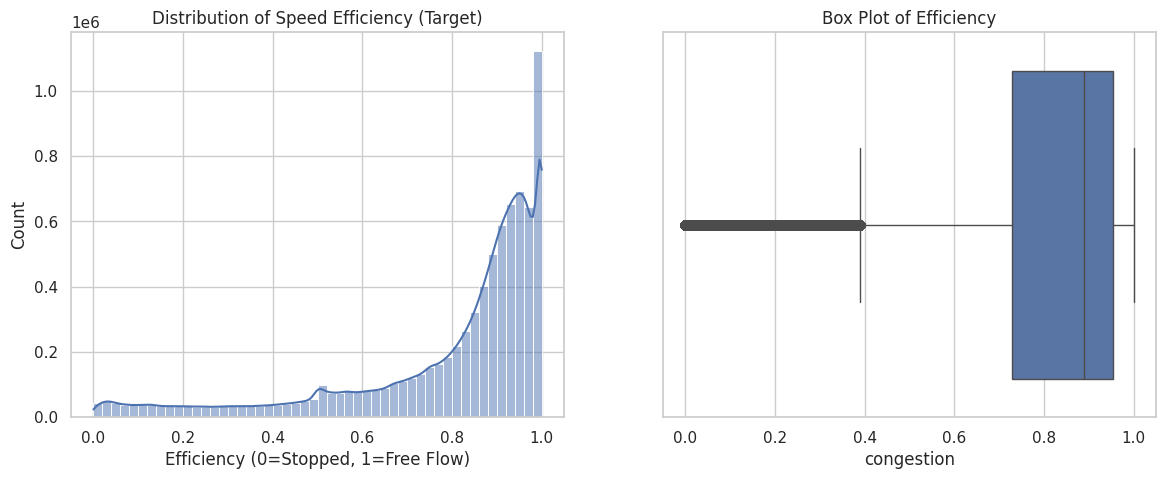

Mean Efficiency: 0.7942
Median Efficiency: 0.8887
% of Data with perfect flow (>0.95): 26.44%


In [2]:
# 2. Analyze Target Distribution
# If the distribution is extremely peaked at 1.0 (Free Flow), the model learns "Always predict 1.0".

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['congestion'], bins=50, kde=True)
plt.title("Distribution of Speed Efficiency (Target)")
plt.xlabel("Efficiency (0=Stopped, 1=Free Flow)")

plt.subplot(1, 2, 2)
sns.boxplot(x=data['congestion'])
plt.title("Box Plot of Efficiency")

plt.show()

mean_target = data['congestion'].mean()
median_target = data['congestion'].median()
print(f"Mean Efficiency: {mean_target:.4f}")
print(f"Median Efficiency: {median_target:.4f}")
print(f"% of Data with perfect flow (>0.95): {(data['congestion'] > 0.95).mean() * 100:.2f}%")

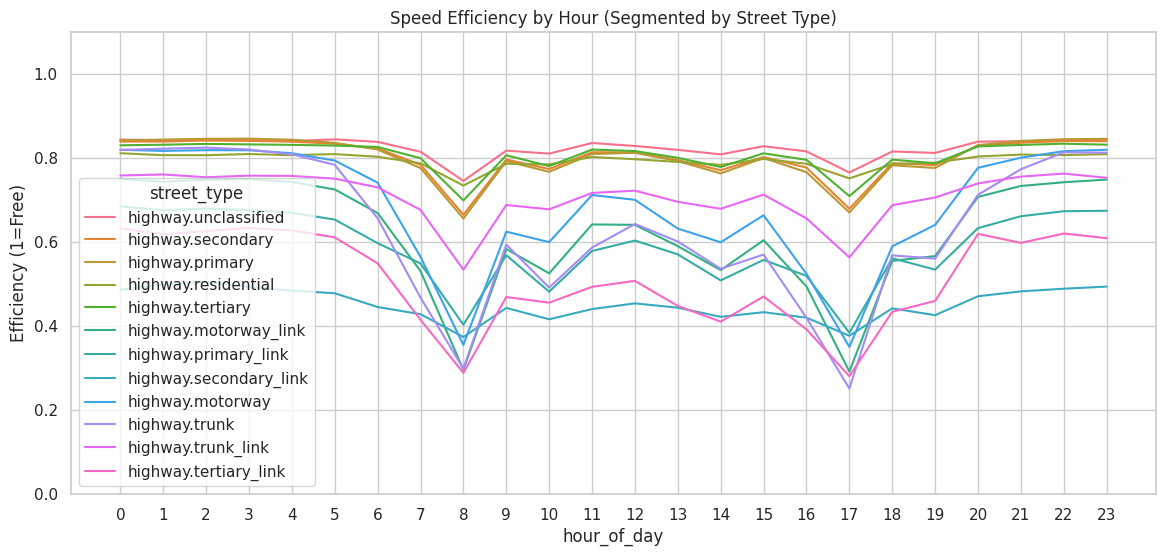

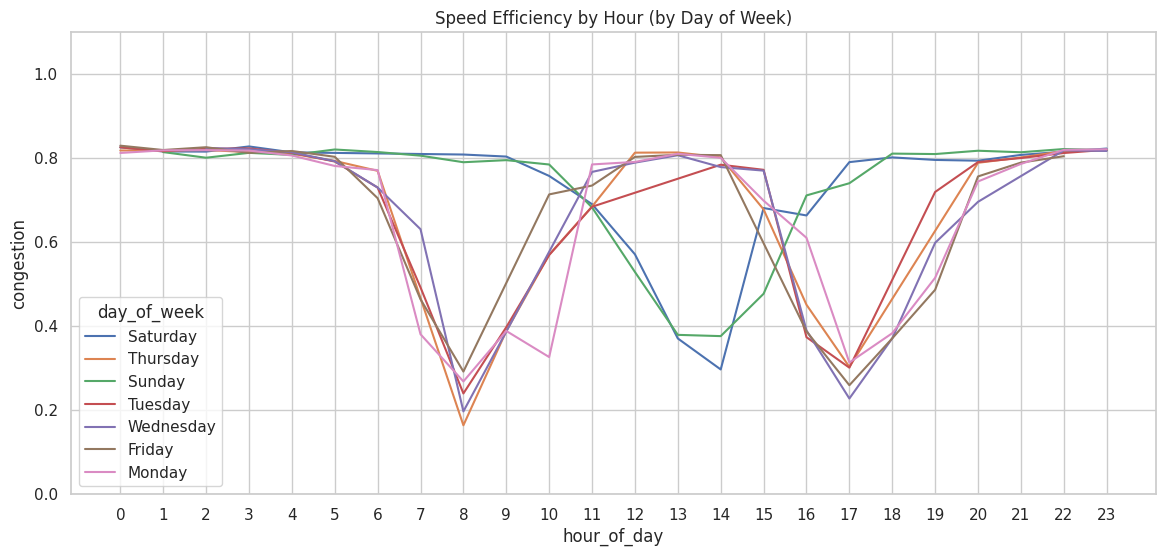

In [3]:
# 3. Segmented Temporal Analysis
# The "Flat Line" artifact might be due to averaging everything together.
# Let's verify if Rush Hour exists for *specific* road types.

plt.figure(figsize=(14, 6))
sns.lineplot(data=data, x="hour_of_day", y="congestion", hue="street_type", errorbar=None)
plt.title("Speed Efficiency by Hour (Segmented by Street Type)")
plt.ylabel("Efficiency (1=Free)")
plt.ylim(0, 1.1)
plt.xticks(range(0, 24))
plt.show()

# Also check Day of Week
plt.figure(figsize=(14, 6))
sns.lineplot(data=data[data["street_type"] == "highway.motorway"],
    x="hour_of_day", y="congestion", hue="day_of_week", errorbar=None)
plt.title("Speed Efficiency by Hour (by Day of Week)")
plt.ylim(0,1.1)
plt.xticks(range(0, 24))
plt.show()

In [4]:
# Congestion variation by street type and day of week
data.groupby("street_type")["congestion"].agg(["mean", "std"]).sort_values("std", ascending=False)

,mean,std
street_type,,
highway.trunk,0.653871,0.372807
highway.primary_link,0.587801,0.367119
highway.tertiary_link,0.495838,0.364786
highway.secondary_link,0.450241,0.324170
highway.motorway_link,0.633891,0.323780
highway.motorway,0.696627,0.296935
highway.trunk_link,0.712488,0.273027
highway.residential,0.786444,0.238698
highway.tertiary,0.804000,0.232143


In [5]:
data.groupby("day_of_week")["congestion"].agg(["max", "min", "mean", "std"])\
    .sort_values("std", ascending=False)

,max,min,mean,std
day_of_week,,,,
Friday,1.0,0.000000e+00,0.783527,0.245937
Wednesday,1.0,5.489056e-08,0.788090,0.243930
Thursday,1.0,2.380673e-07,0.795530,0.237153
Tuesday,1.0,8.597195e-07,0.797656,0.235281
Monday,1.0,0.000000e+00,0.797297,0.234216
Sunday,1.0,9.022005e-07,0.797058,0.233681
Saturday,1.0,0.000000e+00,0.800948,0.230668


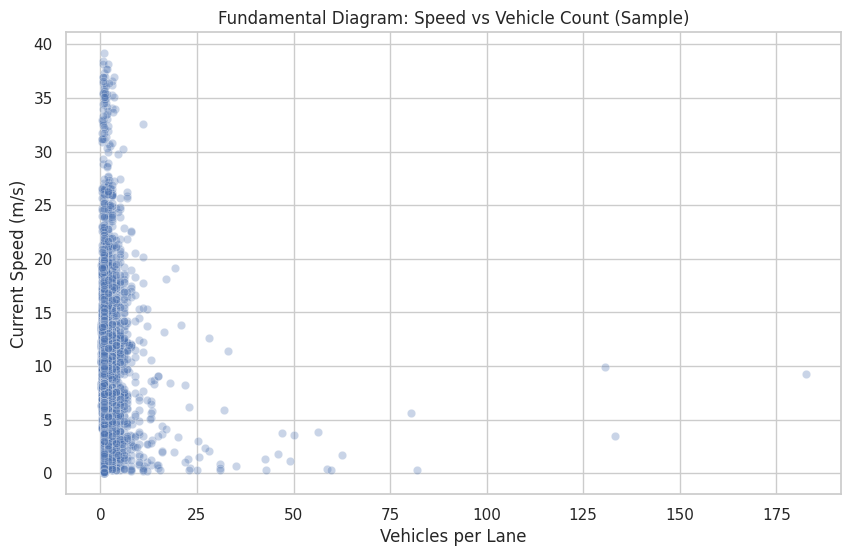

In [6]:
# 4. Fundamental Dynamics: Speed vs Density
# In real traffic, speed = FreeSpeed * (1 - Density/JamDensity).
# We should see a curve. If it's a random cloud, the simulation physics are loose.
# We normalize density as (vehicle_count / lane_count).

data['density_per_lane'] = data['vehicle_count'] / data['lane_count']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data.sample(min(10000, len(data))),
    x="density_per_lane", y="current_speed", alpha=0.3)
plt.title("Fundamental Diagram: Speed vs Vehicle Count (Sample)")
plt.xlabel("Vehicles per Lane")
plt.ylabel("Current Speed (m/s)")
plt.show()

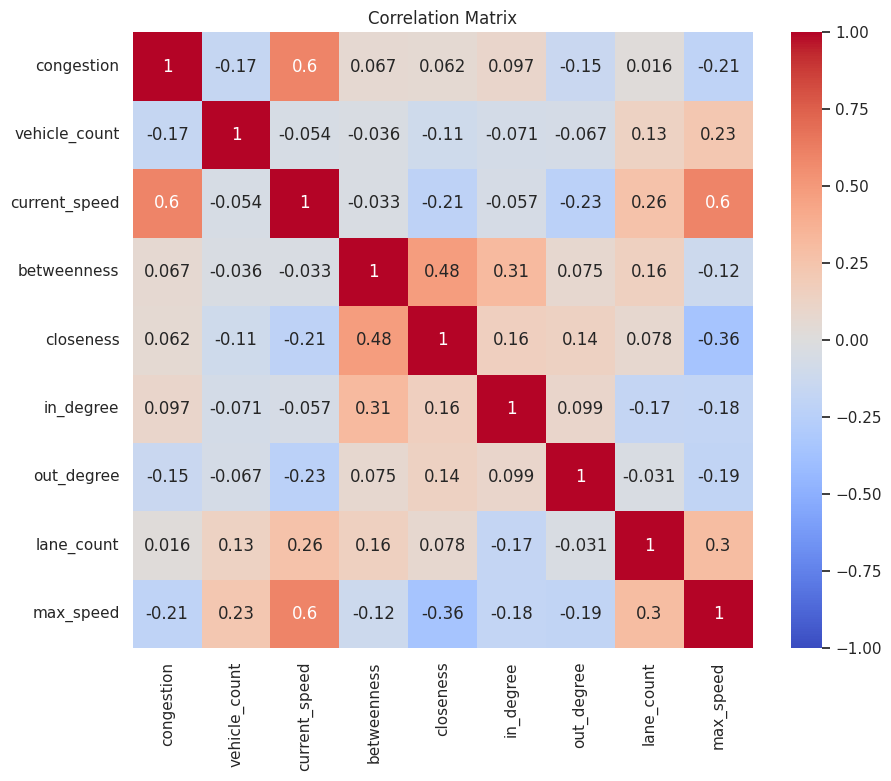

In [7]:
# 5. Correlation Matrix
# Do our new topology features actually correlate with congestion?

# create a subset of numeric columns
numeric_cols = [
    "congestion", "vehicle_count", "current_speed", 
    "betweenness", "closeness", "in_degree", "out_degree",
    "lane_count", "max_speed"
]

corr = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [8]:
# 6. Topology Feature Inspection (Numerical)
# The user noted "Distribution of Betweenness is empty". Let's check the raw numbers.

print("--- Topology Statistics ---")
topo_stats = data[['betweenness', 'closeness']].describe()
print(topo_stats)

zero_betweenness = (data['betweenness'] == 0).sum()
total_rows = len(data)
print(f"Zero Betweenness: {zero_betweenness}/{total_rows}")

unique_betweenness = data['betweenness'].nunique()
print(f"Unique Betweenness Values: {unique_betweenness}")

# Check if we have betweenness for the most common edges
top_edges = data['edge_id'].value_counts().head(5).index.tolist()
print(f"{data[data['edge_id'].isin(top_edges)][['edge_id', 'betweenness']]}")


--- Topology Statistics ---
        betweenness     closeness
count  8.002554e+06  8.002554e+06
mean   2.224919e-02  2.688892e-04
std    2.483858e-02  6.744754e-05
min    0.000000e+00  0.000000e+00
25%    2.860421e-03  2.152112e-04
50%    1.307595e-02  2.836733e-04
75%    3.449762e-02  3.276051e-04
max    1.576810e-01  3.617346e-04

Zero Betweenness Count: 183437 / 8002554 (2.3%)
Unique Betweenness Values: 4350

Sample Betweenness for top 5 edges: 
            edge_id  betweenness
32    -1116935037#1     0.000000
42      -1125080994     0.004676
43      -1125080995     0.004611
2369    986639489#0     0.003173
2371      987803937     0.039877


In [9]:
# 7. Data Coverage Analysis (Numerical)
# User noted "Wednesday doesn't seem to have enough data (cuts off at 16)"
# Let's look at the counts per Day/Hour grid.

coverage = pd.crosstab(data['day_of_week'], data['hour_of_day'])
print("--- Data Point Counts by Day & Hour ---")
print(coverage)

# Check for missing hours
missing_hours = coverage == 0
if missing_hours.any().any():
    print("\n⚠️ GAP DETECTED: We are missing simulation data for these slots:")
    print(missing_hours[missing_hours])

--- Data Point Counts by Day & Hour ---
hour_of_day     0      1      2       3      4      5       6       7   \
day_of_week                                                              
Friday       15896  16853  31153   33762  32789  35192   20293  102062   
Monday       50220  48881  49424   48934  51277  36126   19122   26480   
Saturday     17052  31853  34557   16163  17498      0       0       0   
Sunday           0  32288  34954   15920  33074  17655   16343   32590   
Thursday     48619  50210  48999   65967  83623  71048   19285       0   
Tuesday      32981  32222  32743   49290  83339  71596   40365   75747   
Wednesday        0      0  63877  117896  84662  70873  121227  116390   

hour_of_day      8      9   ...      14     15      16      17     18      19  \
day_of_week                 ...                                                 
Friday       110547      0  ...   53469      0   53542  103259  26651   50361   
Monday        51466  26641  ...   18123  61142   9

In [10]:
# 8. Variance Analysis by Street Type (Numerical)
# User noted "Almost every street type shows little variance".
# Let's quantify which streets actually *change* their speed using Standard Deviation.

street_stats = data.groupby('street_type')['congestion'].agg(['count', 'mean', 'std', 'min', 'max'])
street_stats['std'] = street_stats['std'].fillna(0) # Handle single-record groups
street_stats = street_stats.sort_values('std', ascending=False)

print("--- Congestion Variance by Street Type (High STD = Dynamic) ---")
print(street_stats)

print("\n--- Low Variance Investigation ---")
# If std is low (~0.0), it means the speed NEVER changes from free-flow (or constant jam).
low_var_streets = street_stats[street_stats['std'] < 0.05].index.tolist()
print(f"Static Streets (Speed varies < 5%): {low_var_streets}")

--- Congestion Variance by Street Type (High STD = Dynamic) ---
                          count      mean       std           min  max
street_type                                                           
highway.trunk             25907  0.653871  0.372807  3.805041e-03  1.0
highway.primary_link      27613  0.587801  0.367119  1.090275e-06  1.0
highway.tertiary_link      7982  0.495838  0.364786  1.942814e-06  1.0
highway.secondary_link    42637  0.450241  0.324170  4.100332e-06  1.0
highway.motorway_link     84795  0.633891  0.323780  1.476619e-04  1.0
highway.motorway         101164  0.696627  0.296935  4.426112e-03  1.0
highway.trunk_link         9592  0.712488  0.273027  1.939008e-02  1.0
highway.residential     1753369  0.786444  0.238698  5.180091e-07  1.0
highway.tertiary        1431152  0.804000  0.232143  2.148058e-07  1.0
highway.primary         1432958  0.802186  0.231329  0.000000e+00  1.0
highway.secondary       2349764  0.803285  0.225486  0.000000e+00  1.0
highway.uncla